# First Steps

Lets make some initial imports.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Now we will start design our first A/B test.  
Let's imangine that we want design user-level experiment with ARPU metric.  
Main class we need is `DesignerIid`.  
  
Besides, we need data for our experiment.  
In our educational case we will generate some synthetic data with `RandomData` class.  
Let's start!

In [ ]:
from mcab import RandomData, DesignerIid

In [3]:
# Create random data generator:
rd = RandomData(seed=42)

# Creating np.array from exponential distribution:
aa_data = rd.exponential_data(size=10_000, scale=1_000_000)
print(f'Type: {type(aa_data)}, Shape:{aa_data.shape}')

Type: <class 'numpy.ndarray'>, Shape:(10000,)


Now we have the data. Let's start design!
What we need for design estimation:
- data (allready have)
- pvalue function
- effect strategy
  
Pvalue function can be defined as simple python function with test and control arguments and any code inside.  
We can make Ttest function as follows:

In [4]:
def pval_function(test, control):
    # Any code inside. Should return float pvalue
    return stats.ttest_ind(test, control, equal_var=False).pvalue

# Also could be defined shorter, as lambda function:
pval_function = lambda test, control: stats.ttest_ind(test, control, equal_var=False).pvalue

MCAB has rich effect strategies. We will start with simple case of percentage effect strategy, when we increase effect of test group for a some percent.  
Let's create designer.  

In [5]:
designer = DesignerIid(
    target=aa_data, # pred-experiment data we want to estimate
    alpha=0.05, # alpha for first type error
    effect_sizer='percent', # default
    pval_func=pval_function,
)

# A/A simulations checks  

Let's make A/A simulations:

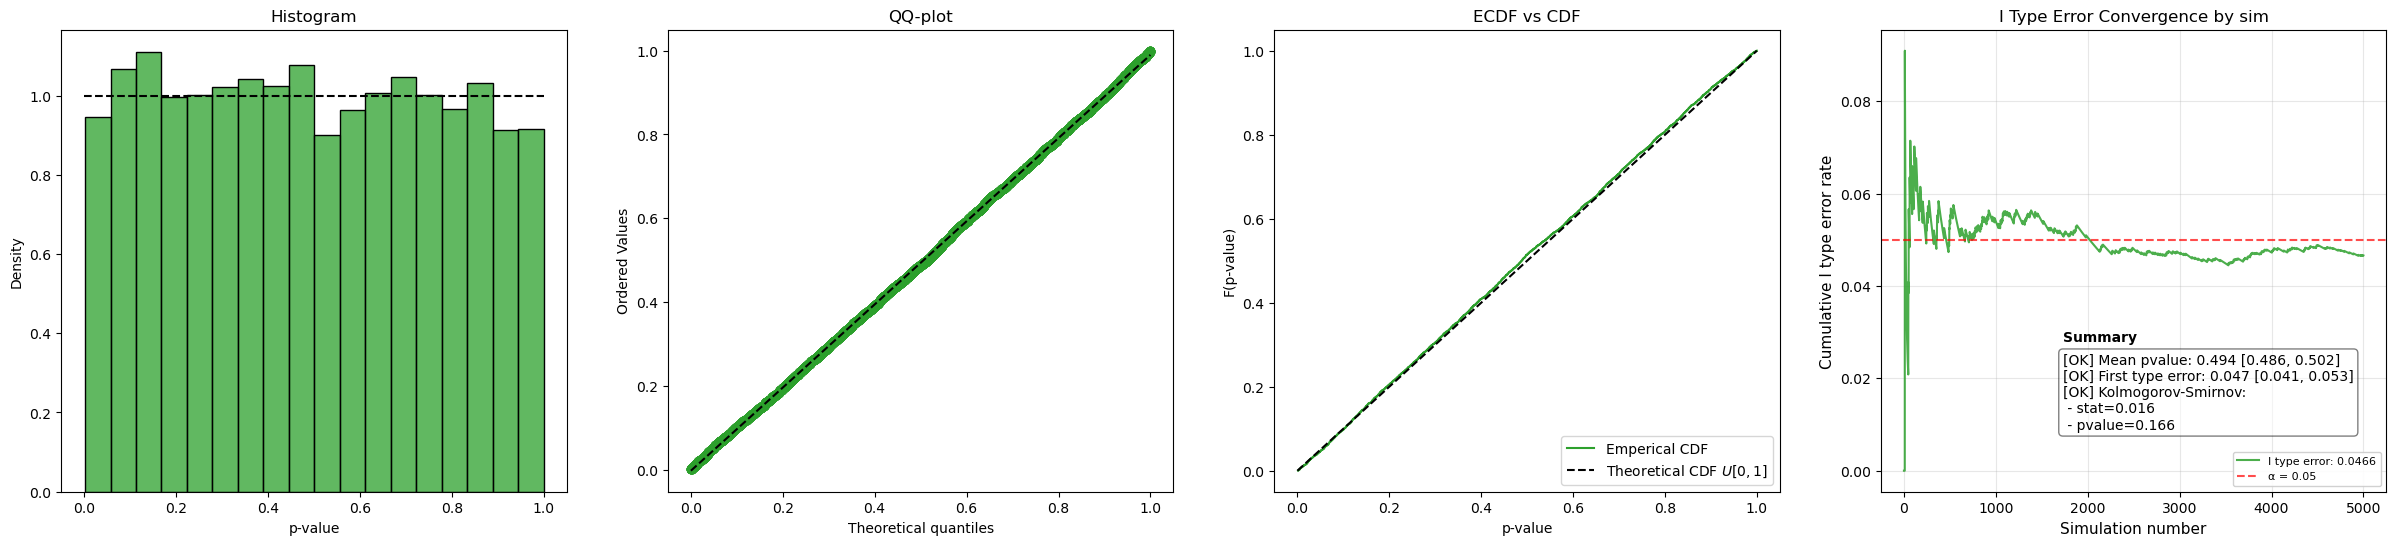

Type: <class 'numpy.ndarray'>, Shape: (5000,)


In [6]:
aa_pvalues = designer.aa_sims(
    n_sims=5_000,
    control_size=0.5,
    verbose=False,
    n_jobs=-1
)
print(f'Type: {type(aa_pvalues)}, Shape: {aa_pvalues.shape}')

We made 5000 simulations and got 5000 p-values without effect assigned to our variable `aa_pvalues` and diagnostical plots drawen below.  

Method `aa_sims` generating pvalues and drawing plots, also it has some checks we well discuss in more details.  
  
## About `aa_sims` method

#### First thing we look in plots - color:
- green - all checks passed, result is good
- yellow or purple - some check failed, result need attention
- red - critical checks failed - result is bad

Now let's discuss all problems separately.

#### Second thing we look in plots - third plot:
Here we have cumulative mean first type error by simulation number.  
If end of this plot doesn't look smooth and stable - we can increase number of simulations and potentially it will solve problems.  

#### Third thing we look in plots - plots:
We should see uniformity of p-values in first three plots by visual analysis.  

#### Fourth thing we look in plots - table in fourth plot:
It contains diagnostical information could be usefull to understand your test problems.  
Each check starts with "\[OK\]" if it's passed, "\[X\]" otherwise.  
Expectable result to be "\[OK\]":
- Mean pvalue: confidence interval should include 0.5
- First type error: left bound of confidence interval should be less than 0.05
- Kolmogorov-Smirnov test: p-value should be greater or equal to 0.05

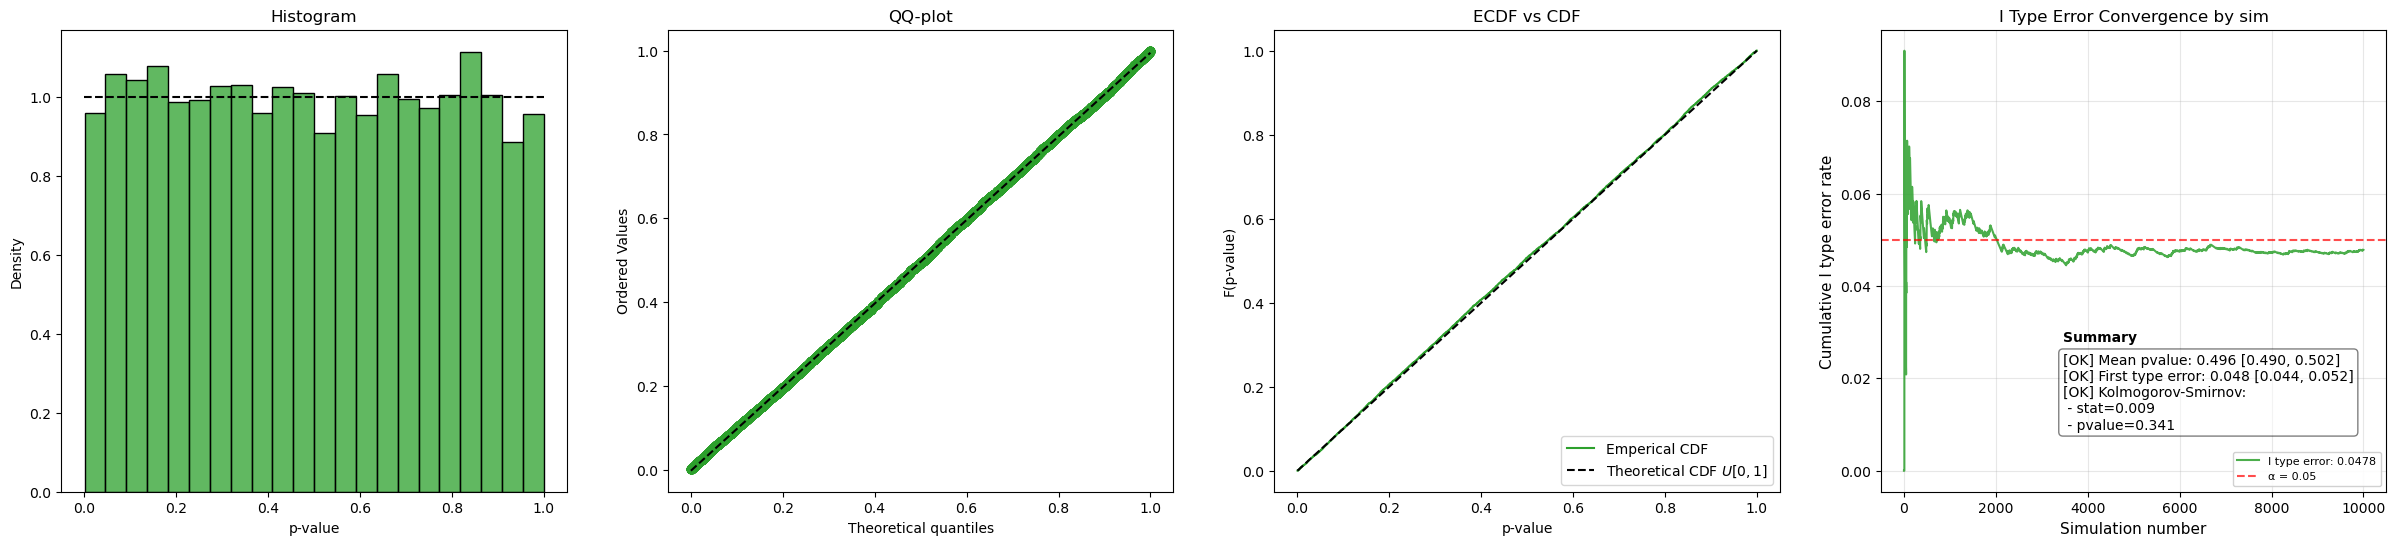

Type: <class 'numpy.ndarray'>, Shape: (10000,)


In [7]:
aa_pvalues = designer.aa_sims(
    n_sims=10_000, # increased from 5_000 to 10_000
    control_size=0.5,
    verbose=False,
    n_jobs=-1
)
print(f'Type: {type(aa_pvalues)}, Shape: {aa_pvalues.shape}')

### Verdict  
We can use ttest for our experiment but another metric or variance reduction could give better design solution.  

# Calculating power and MDE  
  
How we remember, now we use percentage effect sizer we setted when we initialized designer instance.  
So effect 0.01 will be equal for `test_group*1.01` - lets check what power it will reach.

In [8]:
# Will return array of 0 and 1 where 1 is case of pvalue < 0.05
powers = designer.calculate_some_power(
    effect=0.01,
    control_size=0.5,
    n_sims=10_000,
    verbose=False,
    n_jobs=-1
)
# Let's examine the mean:
print(powers.mean())

0.0793


We learned how to estimate power for a single effect.  
Let's draw power curve for multiple effects!

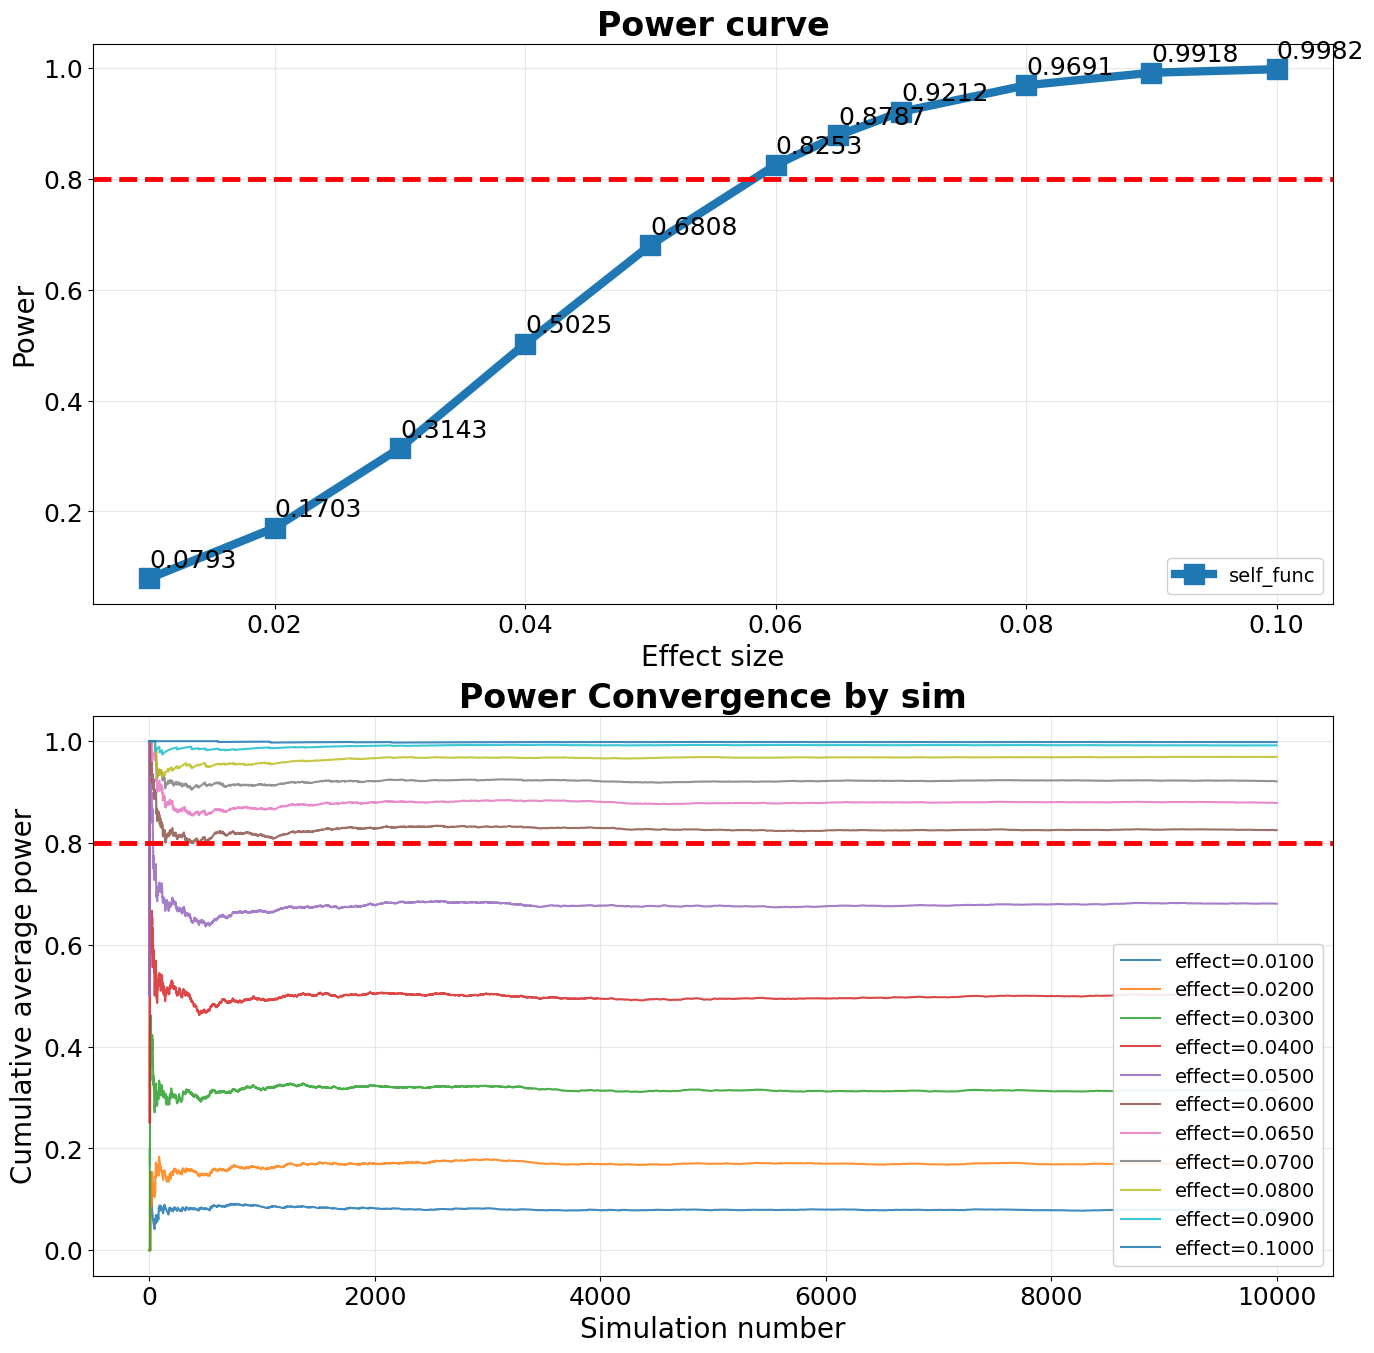

In [9]:
effects_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.065, 0.07, 0.08, 0.09, 0.10]

power_curves = designer.calculate_power_curve(
    effects_list=effects_list,
    n_sims=10_000,
    verbose=False,
    n_jobs=-1
)

We can access estimated powers also by `power_curves` variable:

In [10]:
print(power_curves)

[('self_func', array([0.0793, 0.1703, 0.3143, 0.5025, 0.6808, 0.8253, 0.8787, 0.9212,
       0.9691, 0.9918, 0.9982]))]


In [11]:
for effect, power in zip(effects_list, power_curves[0][1]):
    print(f'Effect: {effect:,.4f}; Power: {power:,.4f}')

Effect: 0.0100; Power: 0.0793
Effect: 0.0200; Power: 0.1703
Effect: 0.0300; Power: 0.3143
Effect: 0.0400; Power: 0.5025
Effect: 0.0500; Power: 0.6808
Effect: 0.0600; Power: 0.8253
Effect: 0.0650; Power: 0.8787
Effect: 0.0700; Power: 0.9212
Effect: 0.0800; Power: 0.9691
Effect: 0.0900; Power: 0.9918
Effect: 0.1000; Power: 0.9982


Usually results for a fixed effect between sims relaunches are close but not equal and this is expectable because we run random simulations and our estimates averagely true but they have some variance.  
By this reason good strategy to pick MDE is to user power_curve analysis and select the one having a little bigger power that you want.  
In our case we can choose between 0.06 and 0.065 effects if we want power 80%.  

### Power analysis and MDE verdict  
We should pick 0.06 or 0.065, 0.065 is more robust.  
  
# Summary and Next steps  
  
We learned how to build Monte Carlo design for a simple experiment.  
In next lessons we will learn how to work with different types of data, apply variance reduction, several designs comparing to select best and making multiple testing corrections.